In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../DataBox/weight-height.csv')

df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

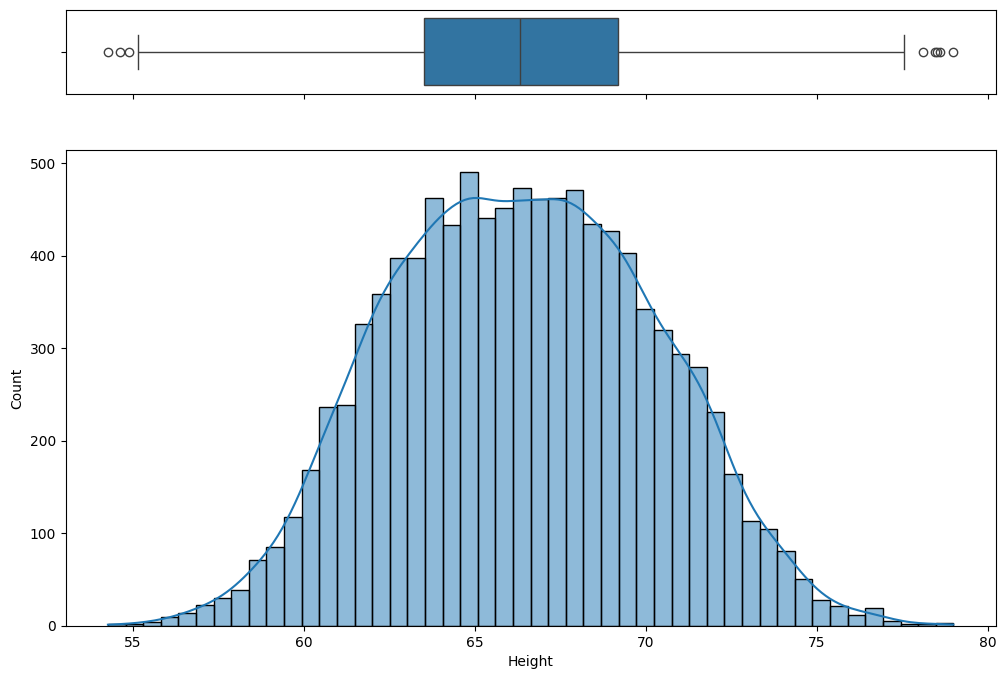

In [3]:
# Verify the Data Distribution
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
 
# BoxPlot and PDF
sns.boxplot(x=df["Height"], ax=ax_box)
sns.histplot(data=df, x="Height", kde=True, ax=ax_hist)

ax_box.set(xlabel='')
plt.show()


Trimming

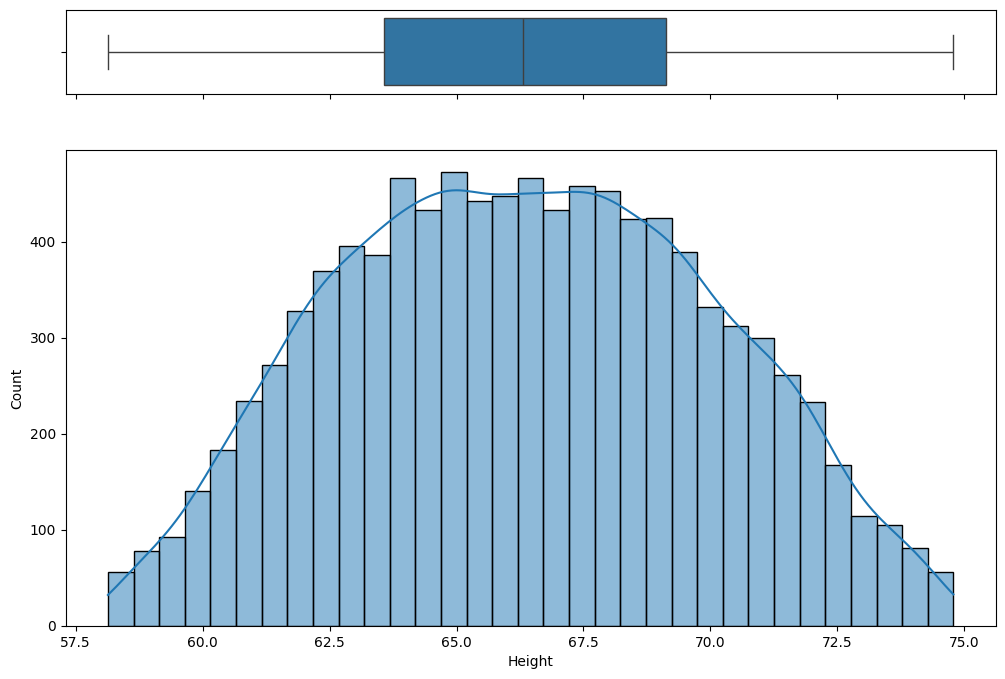

In [4]:
# Decide a Percentile Value for Data Boundary

upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

# Trim and Generate result 
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

# plot and compare
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
 
# BoxPlot and PDF
sns.boxplot(x=new_df["Height"], ax=ax_box)
sns.histplot(data=new_df, x="Height", kde=True, ax=ax_hist)

ax_box.set(xlabel='')
plt.show()

# Observation 
# No subsequent Outliars Observed -> could try Limit +- 1

Winsorization 

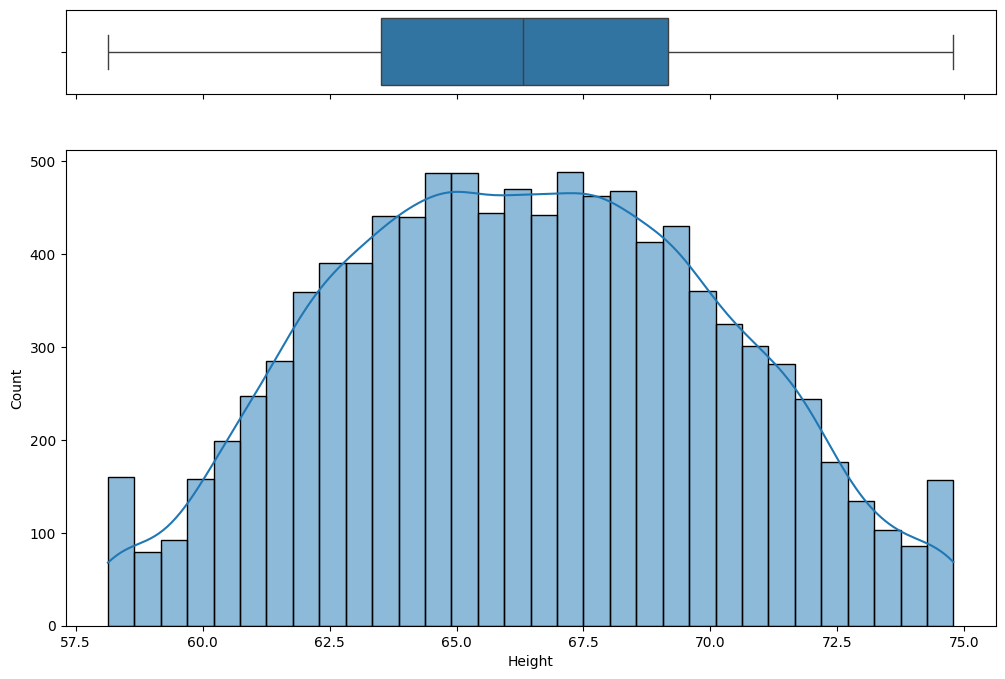

In [5]:
# Capping --> Winsorization

# Generate Data
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

# plot and compare
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))
 
# BoxPlot and PDF
sns.boxplot(x=df["Height"], ax=ax_box)
sns.histplot(data=df, x="Height", kde=True, ax=ax_hist)

ax_box.set(xlabel='')
plt.show()

# Observation 
# Increase In Frequency at both the tails
